In [1]:
from coffea.nanoevents import NanoEventsFactory
import awkward as ak
import numpy as np
import hist
import pandas as pd
import uproot
import json
import glob
import matplotlib.pyplot as plt



/cvmfs/sft.cern.ch/lcg/views/LCG_108_swan/x86_64-el9-gcc13-opt/lib/python3.12/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [2]:
from correctionlib.schemav2 import CorrectionSet, Correction, Variable
from correctionlib.convert import from_histogram
import correctionlib

def evaluator(corr):
    cset = CorrectionSet(schema_version=2, corrections=[corr])
    return np.vectorize(
        correctionlib.CorrectionSet(cset)[corr.name].evaluate,
    )

vptvar = Variable(
    name="hpt",
    type="real",
    description="Generated Higgs boson pT"
)

In [3]:


# https://arxiv.org/pdf/2005.07762.pdf
# Inclusive pT bins
theory_xs = {}
xs_ewkcorr = {}

ptmin = np.array([400,450,500,550,600,650,700,750,800,1200])

theory_xs['VBF'] = np.array([14.23,8.06,4.75,2.90,1.82,1.17,0.77,0.51,0.35])
xs_ewkcorr['VBF'] = np.array([-17.80,-19.43,-21.05,-22.34,-23.73,-25.03,-26.29,-27.35,-28.42])*0.01

theory_xs['VH'] = np.array([11.16,6.87,4.39,2.87,1.91,1.30,0.90,0.62,0.44])
xs_ewkcorr['VH'] = np.array([-19.05,-20.83,-22.50,-24.07,-25.56,-26.98,-28.30,-29.60,-30.83])*0.01

theory_xs['ttH'] = np.array([6.89,4.24,2.66,1.76,1.11,0.72,0.47,0.32,0.22])
xs_ewkcorr['ttH'] = np.array([-6.95,-7.75,-8.49,-9.11,-9.91,-10.67,-11.37,-11.94,-12.51])*0.01



In [4]:
# apply the EW corrections
def ew_xs(xs,corr):
    return np.multiply(xs,1+corr)

# Make the bins exclusive
def make_excl(th):
    excl = -1*np.diff(th)
    return np.append(excl,[th[-1]])

In [5]:
def binning(idx, shift):
    epsilon = np.zeros(113)
    epsilon[idx] = shift
    return {
        "nodetype": "binning",
        "input": "vpt",
        "edges": list(vptproc.edges),
        "content": list(evj_qcd(epsilon) / den),
        "flow": "clamp",
    }

Without EW corr [6.17 3.31 1.85 1.08 0.65 0.4  0.26 0.16 0.35]
With EW corr [5.203118 2.743817 1.497985 0.864026 0.510965 0.309582 0.197052 0.119985
 0.25053 ]
Weights [0.84329303 0.82894773 0.80972162 0.80002407 0.7861     0.773955
 0.75789231 0.74990625 0.7158    ]


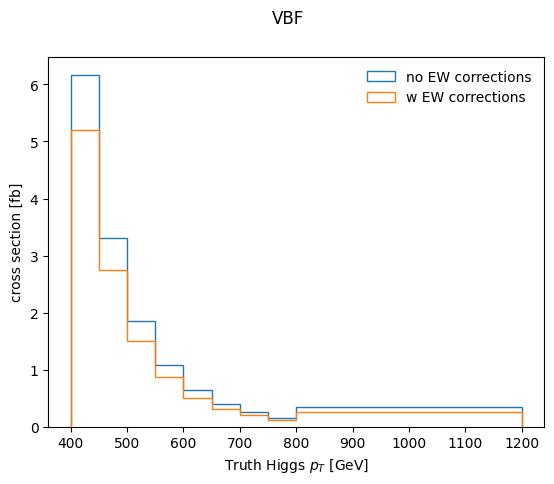

In [6]:
p = 'VBF'
noewcorr = make_excl(theory_xs[p])
yesewcorr = make_excl(ew_xs(theory_xs[p],xs_ewkcorr[p]))
print('Without EW corr',noewcorr)
print('With EW corr',yesewcorr)

weights = np.divide(yesewcorr,noewcorr)
print('Weights',weights)

VBF = Correction(
    name="VBF",
    version=1,
    description="Electroweak correction to VBF Higgs production",
    inputs=[vptvar],
    output=Variable(name="out", type="real", description="Multiplicative k-factor"),
    data={
        "nodetype": "binning",
        "input": "hpt",
        "edges": list(ptmin),
        "content": list(weights),
        "flow": "clamp",
    },
)

plt.hist(x=ptmin[:-1],weights=noewcorr,bins=ptmin,histtype='step',label='no EW corrections')
plt.hist(x=ptmin[:-1],weights=yesewcorr,bins=ptmin,histtype='step',label='w EW corrections')
plt.legend(frameon=False)
plt.suptitle(p);
plt.xlabel(r'Truth Higgs $p_{T}$ [GeV]');
plt.ylabel('cross section [fb]');

/tmp/ipykernel_535/4294915724.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


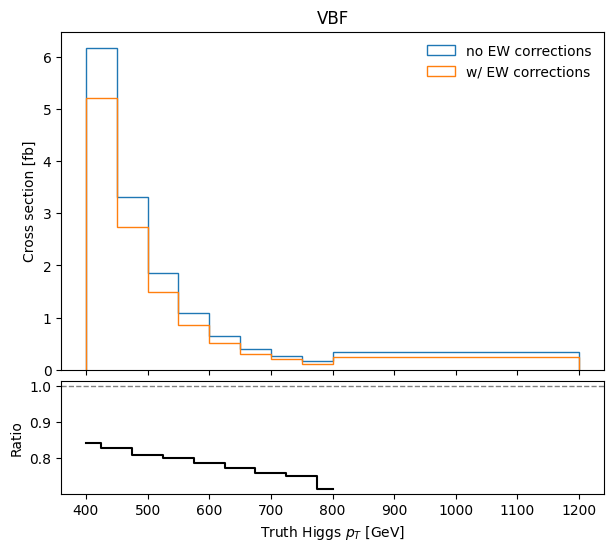

In [7]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2, 
    ncols=1, 
    figsize=(7, 6), 
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Main histogram ---
ax1.hist(
    x=ptmin[:-1],
    weights=noewcorr,
    bins=ptmin,
    histtype='step',
    label='no EW corrections'
)
ax1.hist(
    x=ptmin[:-1],
    weights=yesewcorr,
    bins=ptmin,
    histtype='step',
    label='w/ EW corrections'
)
ax1.legend(frameon=False)
ax1.set_ylabel('Cross section [fb]')
ax1.set_title(p)

# --- Ratio plot ---
ratio = np.divide(
    yesewcorr, 
    noewcorr, 
    out=np.zeros_like(yesewcorr), 
    where=noewcorr != 0
)
ax2.plot(ptmin[:-1], ratio, drawstyle='steps-mid', color='black')
ax2.set_xlabel(r'Truth Higgs $p_{T}$ [GeV]')
ax2.set_ylabel('Ratio')
ax2.axhline(1.0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

Without EW corr [4.29 2.48 1.52 0.96 0.61 0.4  0.28 0.18 0.44]
With EW corr [3.595041 2.036729 1.223059 0.757387 0.472544 0.30396  0.20882  0.132132
 0.304348]


Text(0, 0.5, 'cross section [fb]')

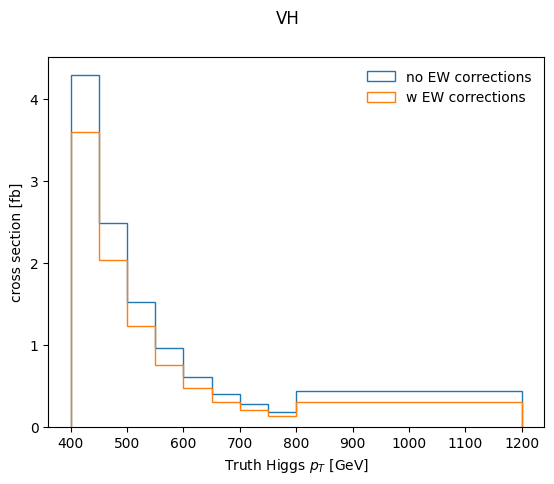

In [8]:
p = 'VH'
noewcorr = make_excl(theory_xs[p])
yesewcorr = make_excl(ew_xs(theory_xs[p],xs_ewkcorr[p]))
print('Without EW corr',noewcorr)
print('With EW corr',yesewcorr)

VH = Correction(
    name="VH",
    version=1,
    description="Electroweak correction to VH Higgs production",
    inputs=[vptvar],
    output=Variable(name="out", type="real", description="Multiplicative k-factor"),
    data={
        "nodetype": "binning",
        "input": "hpt",
        "edges": list(ptmin),
        "content": list(weights),
        "flow": "clamp",
    },
)

plt.hist(x=ptmin[:-1],weights=noewcorr,bins=ptmin,histtype='step',label='no EW corrections')
plt.hist(x=ptmin[:-1],weights=yesewcorr,bins=ptmin,histtype='step',label='w EW corrections')
plt.legend(frameon=False)
plt.suptitle(p)
plt.xlabel(r'Truth Higgs $p_{T}$ [GeV]')
plt.ylabel('cross section [fb]')


/tmp/ipykernel_535/4294915724.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


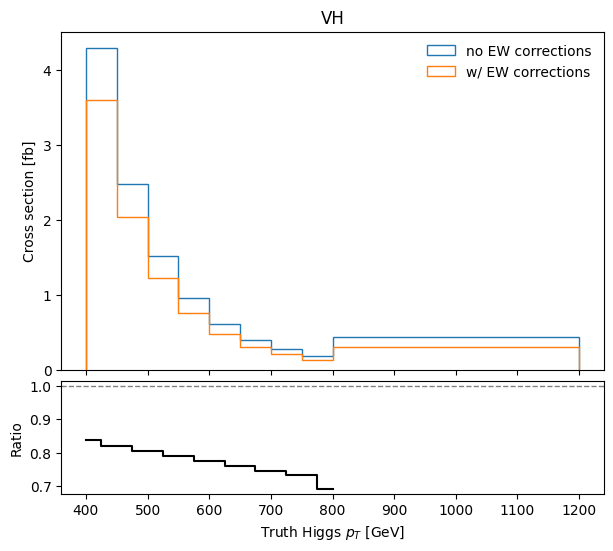

In [9]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2, 
    ncols=1, 
    figsize=(7, 6), 
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Main histogram ---
ax1.hist(
    x=ptmin[:-1],
    weights=noewcorr,
    bins=ptmin,
    histtype='step',
    label='no EW corrections'
)
ax1.hist(
    x=ptmin[:-1],
    weights=yesewcorr,
    bins=ptmin,
    histtype='step',
    label='w/ EW corrections'
)
ax1.legend(frameon=False)
ax1.set_ylabel('Cross section [fb]')
ax1.set_title(p)

# --- Ratio plot ---
ratio = np.divide(
    yesewcorr, 
    noewcorr, 
    out=np.zeros_like(yesewcorr), 
    where=noewcorr != 0
)
ax2.plot(ptmin[:-1], ratio, drawstyle='steps-mid', color='black')
ax2.set_xlabel(r'Truth Higgs $p_{T}$ [GeV]')
ax2.set_ylabel('Ratio')
ax2.axhline(1.0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

Without EW corr [2.65 1.58 0.9  0.65 0.39 0.25 0.15 0.1  0.22]
With EW corr [2.499745 1.477234 0.834502 0.599665 0.356823 0.226615 0.134769 0.089314
 0.192478]


Text(0, 0.5, 'cross section [fb]')

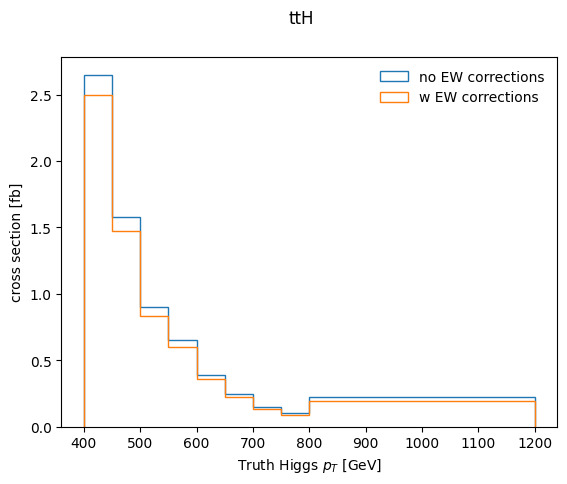

In [10]:
p = 'ttH'
noewcorr = make_excl(theory_xs[p])
yesewcorr = make_excl(ew_xs(theory_xs[p],xs_ewkcorr[p]))
print('Without EW corr',noewcorr)
print('With EW corr',yesewcorr)

ttH = Correction(
    name="ttH",
    version=1,
    description="Electroweak correction to ttH Higgs production",
    inputs=[vptvar],
    output=Variable(name="out", type="real", description="Multiplicative k-factor"),
    data={
        "nodetype": "binning",
        "input": "hpt",
        "edges": list(ptmin),
        "content": list(weights),
        "flow": "clamp",
    },
)

plt.hist(x=ptmin[:-1],weights=noewcorr,bins=ptmin,histtype='step',label='no EW corrections')
plt.hist(x=ptmin[:-1],weights=yesewcorr,bins=ptmin,histtype='step',label='w EW corrections')
plt.legend(frameon=False)
plt.suptitle(p)
plt.xlabel(r'Truth Higgs $p_{T}$ [GeV]')
plt.ylabel('cross section [fb]')

/tmp/ipykernel_535/4294915724.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


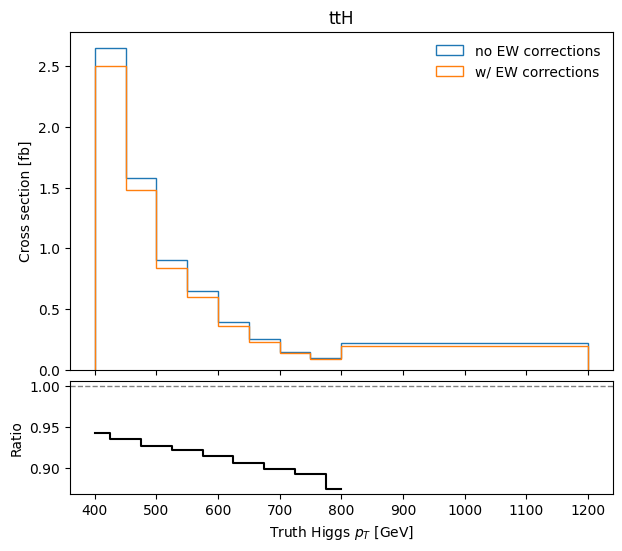

In [11]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2, 
    ncols=1, 
    figsize=(7, 6), 
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Main histogram ---
ax1.hist(
    x=ptmin[:-1],
    weights=noewcorr,
    bins=ptmin,
    histtype='step',
    label='no EW corrections'
)
ax1.hist(
    x=ptmin[:-1],
    weights=yesewcorr,
    bins=ptmin,
    histtype='step',
    label='w/ EW corrections'
)
ax1.legend(frameon=False)
ax1.set_ylabel('Cross section [fb]')
ax1.set_title(p)

# --- Ratio plot ---
ratio = np.divide(
    yesewcorr, 
    noewcorr, 
    out=np.zeros_like(yesewcorr), 
    where=noewcorr != 0
)
ax2.plot(ptmin[:-1], ratio, drawstyle='steps-mid', color='black')
ax2.set_xlabel(r'Truth Higgs $p_{T}$ [GeV]')
ax2.set_ylabel('Ratio')
ax2.axhline(1.0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

In [12]:
cset = CorrectionSet(
    schema_version=2,
    corrections=[VBF, VH, ttH]
)

import rich

rich.print(cset)
with open("EWHiggsCorrections.json", "w") as fout:
    fout.write(cset.json(exclude_unset=True))


CorrectionSet (schema v2)
No description
📂
├── 📈 VBF (v1)
│   Electroweak correction to VBF Higgs production
│   Node counts: Binning: 1
│   ╭────────────── ▶ input ──────────────╮
│   │ hpt (real)                          │
│   │ Generated Higgs boson pT            │
│   │ Range: [400.0, 1200.0), overflow ok │
│   ╰─────────────────────────────────────╯
│   ╭─────── ◀ output ────────╮
│   │ out (real)              │
│   │ Multiplicative k-factor │
│   ╰─────────────────────────╯
├── 📈 VH (v1)
│   Electroweak correction to VH Higgs production
│   Node counts: Binning: 1
│   ╭────────────── ▶ input ──────────────╮
│   │ hpt (real)                          │
│   │ Generated Higgs boson pT            │
│   │ Range: [400.0, 1200.0), overflow ok │
│   ╰─────────────────────────────────────╯
│   ╭─────── ◀ output ────────╮
│   │ out (real)              │
│   │ Multiplicative k-factor │
│   ╰─────────────────────────╯
└── 📈 ttH (v1)
    Electroweak correction to ttH Higgs production
    Node counts: Binning: 1
    ╭────────────── ▶ input ──────────────╮
    │ hpt (real)                          │
    │ Generated Higgs boson pT            │
    │ Range: [400.0, 1200.0), overflow ok │
    ╰─────────────────────────────────────╯
    ╭─────── ◀ output ────────╮
    │ out (real)              │
    │ Multiplicative k-factor │
    ╰─────────────────────────╯

/tmp/ipykernel_535/2533000324.py:10: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  fout.write(cset.json(exclude_unset=True))


In [13]:
def fit_and_extrapolate_ratio(
    pt_edges,
    ratio,
    fit_min=400,
    fit_max=800,
    pt_min=0,
    pt_max=1200,
    step=10,
):
    # original bin centers
    centers = 0.5 * (pt_edges[:-1] + pt_edges[1:])

    # fit region: 400–800
    fit_mask = (centers >= fit_min) & (centers <= fit_max)
    fit_x = centers[fit_mask]
    fit_y = ratio[fit_mask]

    # linear fit
    coeffs = np.polyfit(fit_x, fit_y, 1)
    poly = np.poly1d(coeffs)

    # extrapolation grid
    new_edges = np.arange(pt_min, pt_max + step, step)
    new_centers = 0.5 * (new_edges[:-1] + new_edges[1:])
    new_ratio = poly(new_centers)

    return poly, new_edges, new_centers, new_ratio


In [14]:
results = {}

for p in ["VBF", "VH", "ttH"]:
    noewcorr = make_excl(theory_xs[p])
    yesewcorr = make_excl(ew_xs(theory_xs[p], xs_ewkcorr[p]))

    ratio = np.divide(
        yesewcorr,
        noewcorr,
        out=np.zeros_like(yesewcorr),
        where=noewcorr != 0
    )

    centers = 0.5 * (ptmin[:-1] + ptmin[1:])

    # keep ONLY original bins up to 800
    keep_mask = centers <= 800
    kept_edges = ptmin[np.append(keep_mask, False)]
    kept_edges = np.append(kept_edges, 800)
    kept_ratio = ratio[keep_mask]

    poly, new_edges, new_centers, new_ratio = fit_and_extrapolate_ratio(
        ptmin, ratio
    )

    results[p] = {
        "ratio": kept_ratio,
        "edges": kept_edges,
        "centers": centers[keep_mask],
        "poly": poly,
        "new_edges": new_edges,
        "new_centers": new_centers,
        "new_ratio": new_ratio,
    }


In [19]:
combined_corrections = {}

for p, res in results.items():

    # regions
    low_mask = res["new_centers"] < 400
    high_mask = res["new_centers"] > 800

    low_edges = res["new_edges"][low_mask.tolist() + [False]]
    low_ratio = res["new_ratio"][low_mask]

    high_edges = res["new_edges"][np.where(high_mask)[0][0]:]
    high_ratio = res["new_ratio"][high_mask]

    # merge edges and contents
    merged_edges = np.concatenate([
        low_edges,
        res["edges"],      # original 400–800
        high_edges[1:]     # avoid duplicate 800
    ])

    merged_ratio = np.concatenate([
        low_ratio,
        res["ratio"],
        high_ratio
    ])

    corr = Correction(
        name=f"{p}",
        version=1,
        description=(
            f"EW correction for {p}: "
            "linear fit (400–800 GeV), "
            "extrapolated <400 and >800 GeV, "
            "original theory bins used in fit region"
        ),
        inputs=[vptvar],
        output=Variable(name="out", type="real", description="Multiplicative k-factor"),
        data={
            "nodetype": "binning",
            "input": "hpt",
            "edges": list(merged_edges),
            "content": list(merged_ratio),
            "flow": "clamp",
        },
    )

    combined_corrections[p] = corr


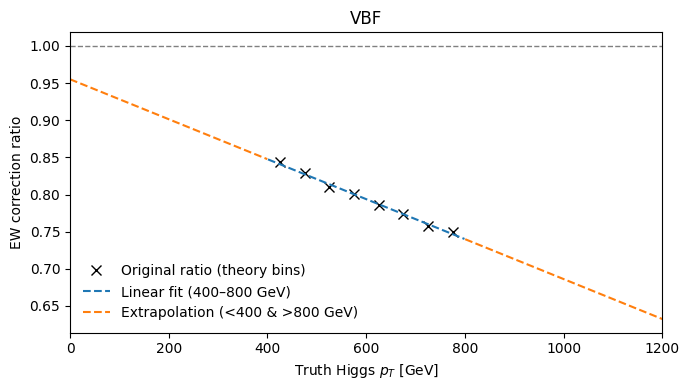

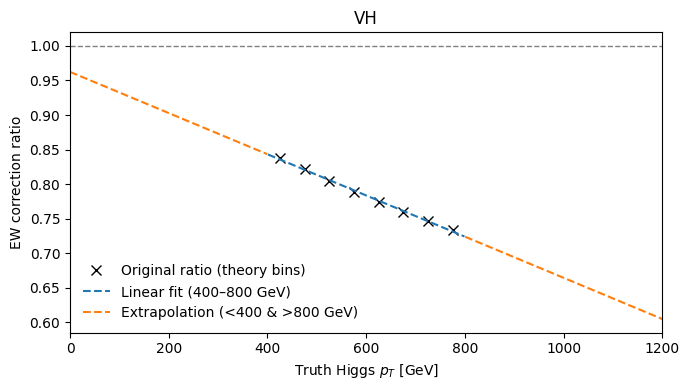

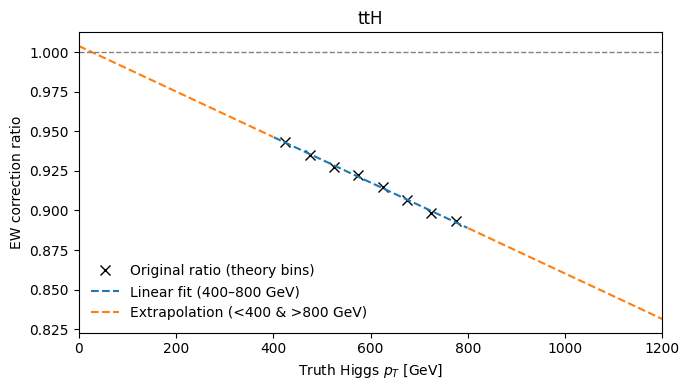

In [20]:
for p, res in results.items():
    fig, ax = plt.subplots(figsize=(7, 4))

    # original theory points (≤800 only)
    ax.plot(
        res["centers"],
        res["ratio"],
        linestyle="None",
        marker="x",
        markersize=7,
        color="black",
        label="Original ratio (theory bins)"
    )

    x_all = np.linspace(0, 1200, 800)

    x_fit = x_all[(x_all >= 400) & (x_all <= 800)]
    x_extr_low = x_all[x_all < 400]
    x_extr_high = x_all[x_all > 800]

    ax.plot(
        x_fit,
        res["poly"](x_fit),
        color="C0",
        linestyle="--",
        label="Linear fit (400–800 GeV)"
    )

    ax.plot(
        x_extr_low,
        res["poly"](x_extr_low),
        color="C1",
        linestyle="--",
        label="Extrapolation (<400 & >800 GeV)"
    )
    ax.plot(
        x_extr_high,
        res["poly"](x_extr_high),
        color="C1",
        linestyle="--"
    )

    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(0, 1200)

    ax.set_xlabel(r"Truth Higgs $p_T$ [GeV]")
    ax.set_ylabel("EW correction ratio")
    ax.set_title(p)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()


In [21]:
import json
import rich

cset = CorrectionSet(
    schema_version=2,
    corrections=list(combined_corrections.values())
)

with open("EWHiggsCorrections_COMBINED.json", "w") as fout:
    fout.write(cset.json(exclude_unset=True))

with open("EWHiggsCorrections_COMBINED.json") as fin:
    rich.print(json.load(fin))


/tmp/ipykernel_535/533691749.py:10: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  fout.write(cset.json(exclude_unset=True))


{
    'schema_version': 2,
    'corrections': [
        {
            'name': 'VBF',
            'description': 'EW correction for VBF: linear fit (400–800 GeV), extrapolated <400 and >800 GeV, 
original theory bins used in fit region',
            'version': 1,
            'inputs': [{'name': 'hpt', 'type': 'real', 'description': 'Generated Higgs boson pT'}],
            'output': {'name': 'out', 'type': 'real', 'description': 'Multiplicative k-factor'},
            'data': {
                'nodetype': 'binning',
                'input': 'hpt',
                'edges': [
                    0.0,
                    10.0,
                    20.0,
                    30.0,
                    40.0,
                    50.0,
                    60.0,
                    70.0,
                    80.0,
                    90.0,
                    100.0,
                    110.0,
                    120.0,
                    130.0,
                    140.0,
                    150.0,
                    160.0,
                    170.0,
                    180.0,
                    190.0,
                    200.0,
                    210.0,
                    220.0,
                    230.0,
                    240.0,
                    250.0,
                    260.0,
                    270.0,
                    280.0,
                    290.0,
                    300.0,
                    310.0,
                    320.0,
                    330.0,
                    340.0,
                    350.0,
                    360.0,
                    370.0,
                    380.0,
                    390.0,
                    400.0,
                    450.0,
                    500.0,
                    550.0,
                    600.0,
                    650.0,
                    700.0,
                    750.0,
                    800.0,
                    810.0,
                    820.0,
                    830.0,
                    840.0,
                    850.0,
                    860.0,
                    870.0,
                    880.0,
                    890.0,
                    900.0,
                    910.0,
                    920.0,
                    930.0,
                    940.0,
                    950.0,
                    960.0,
                    970.0,
                    980.0,
                    990.0,
                    1000.0,
                    1010.0,
                    1020.0,
                    1030.0,
                    1040.0,
                    1050.0,
                    1060.0,
                    1070.0,
                    1080.0,
                    1090.0,
                    1100.0,
                    1110.0,
                    1120.0,
                    1130.0,
                    1140.0,
                    1150.0,
                    1160.0,
                    1170.0,
                    1180.0,
                    1190.0,
                    1200.0
                ],
                'content': [
                    0.9538428783270936,
                    0.9511519056205903,
                    0.9484609329140868,
                    0.9457699602075834,
                    0.9430789875010801,
                    0.9403880147945767,
                    0.9376970420880733,
                    0.9350060693815699,
                    0.9323150966750665,
                    0.9296241239685631,
                    0.9269331512620598,
                    0.9242421785555563,
                    0.9215512058490529,
                    0.9188602331425496,
                    0.9161692604360462,
                    0.9134782877295429,
                    0.9107873150230394,
                    0.908096342316536,
                    0.9054053696100327,
                    0.9027143969035293,
                    0.9000234241970259,
                    0.8973324514905225,
                    0.8946414787840191,
                    0.8919505060775157,
 

In [22]:
with open("EWHiggsCorrections.json") as fin:
    rich.print(json.load(fin))


{
    'schema_version': 2,
    'corrections': [
        {
            'name': 'VBF',
            'description': 'Electroweak correction to VBF Higgs production',
            'version': 1,
            'inputs': [{'name': 'hpt', 'type': 'real', 'description': 'Generated Higgs boson pT'}],
            'output': {'name': 'out', 'type': 'real', 'description': 'Multiplicative k-factor'},
            'data': {
                'nodetype': 'binning',
                'input': 'hpt',
                'edges': [400.0, 450.0, 500.0, 550.0, 600.0, 650.0, 700.0, 750.0, 800.0, 1200.0],
                'content': [
                    0.8432930307941653,
                    0.8289477341389729,
                    0.8097216216216215,
                    0.8000240740740742,
                    0.7860999999999997,
                    0.773955,
                    0.7578923076923079,
                    0.7499062499999999,
                    0.7158
                ],
                'flow': 'clamp'
            }
        },
        {
            'name': 'VH',
            'description': 'Electroweak correction to VH Higgs production',
            'version': 1,
            'inputs': [{'name': 'hpt', 'type': 'real', 'description': 'Generated Higgs boson pT'}],
            'output': {'name': 'out', 'type': 'real', 'description': 'Multiplicative k-factor'},
            'data': {
                'nodetype': 'binning',
                'input': 'hpt',
                'edges': [400.0, 450.0, 500.0, 550.0, 600.0, 650.0, 700.0, 750.0, 800.0, 1200.0],
                'content': [
                    0.8432930307941653,
                    0.8289477341389729,
                    0.8097216216216215,
                    0.8000240740740742,
                    0.7860999999999997,
                    0.773955,
                    0.7578923076923079,
                    0.7499062499999999,
                    0.7158
                ],
                'flow': 'clamp'
            }
        },
        {
            'name': 'ttH',
            'description': 'Electroweak correction to ttH Higgs production',
            'version': 1,
            'inputs': [{'name': 'hpt', 'type': 'real', 'description': 'Generated Higgs boson pT'}],
            'output': {'name': 'out', 'type': 'real', 'description': 'Multiplicative k-factor'},
            'data': {
                'nodetype': 'binning',
                'input': 'hpt',
                'edges': [400.0, 450.0, 500.0, 550.0, 600.0, 650.0, 700.0, 750.0, 800.0, 1200.0],
                'content': [
                    0.8432930307941653,
                    0.8289477341389729,
                    0.8097216216216215,
                    0.8000240740740742,
                    0.7860999999999997,
                    0.773955,
                    0.7578923076923079,
                    0.7499062499999999,
                    0.7158
                ],
                'flow': 'clamp'
            }
        }
    ]
}